# Capstone Project: Introduction to Machine Learning (2026)
## Course Cancellation Prediction – Nova Academy

**Submitted by:** Yahli Efrati & Doron Bachar  
**Group Number:** 31  


---

### Project Description & Business Objective
Nova Academy provides advanced B2B technology training, requiring significant upfront investments in cloud labs, catering, and logistics. This project develops a machine learning pipeline to predict the probability of a course registration being canceled (`Dropped_Course`) using historical CRM data. 

The primary business objective is to minimize financial losses resulting from over-provisioning and empty seats, enabling proactive resource optimization and capacity management.

---

In [133]:
# ==============================================================================
# STEP 1: LIBRARY IMPORTS & ENVIRONMENT SETUP
# ==============================================================================

# Core Data Science Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Technical & Mathematical Utilities
import math
from typing import List, Dict, Tuple, Optional

# Machine Learning & Preprocessing (Scikit-Learn)
# Note: Preparing imports for future handling of missing values & evaluations
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Global Visual Settings for Scannability and Clarity
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Verification Message
print("✓ Environment successfully configured. All libraries imported.")

✓ Environment successfully configured. All libraries imported.


## Part A: EDA - Data Understanding / Exploration

In this section, we load the dataset and perform an initial inspection to understand its structure, dimensions, data types,distributions and  missing values.

In [134]:
# Load the training dataset
df_train = pd.read_csv(r'C:\DF_in_LocalDisk\Train_Data.csv')

# Display the first 5 rows
df_train.head()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


In [135]:
# 1. Get a summary of columns, data types, and non-null counts
print("--- Dataframe Info ---")
df_train.info()
 
print("\n" + "="*50 + "\n")
 
# 2. Get statistical summary for numerical features
print("--- Statistical Summary ---")
df_train.describe()

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    63464 non-null  int64  
 1   Professionals_Count          63464 non-null  int64  
 2   Students_Count               63460 non-null  float64
 3   Observers_Count              63464 non-null  int64  
 4   Course_Start_Date            63464 non-null  object 
 5   Practical_Hours              63464 non-null  int64  
 6   Theory_Hours                 63464 non-null  int64  
 7   Registration_Days_Before     60798 non-null  float64
 8   Origin_Country               62907 non-null  object 
 9   Catering_Package             63057 non-null  object 
 10  Welcome_Gift_Type            63464 non-null  object 
 11  Requested_Lab_Config         61728 non-null  object 
 12  Assigned_Lab_Config          63464 non-null  object

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,52291.000000,3120.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,197.834752,5119.021474,98.847963,0.414392
std,22878.980699,0.508607,294.238584,0.089662,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,47.393068,70.106299,41.855391,0.492621
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5002.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5146.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000


### 1.1 Target Variable & Initial Outlier Detection
To establish a solid "Data Story," we first analyze the distribution of our target variable (`Dropped_Course`) to check for class imbalance. Following this, we visually inspect key numerical features that exhibited extreme values during the statistical summary phase (`df.describe()`), specifically targeting `Students_Count` and `Practical_Hours`.

* **Target Class Balance:** Understanding whether the dataset is skewed toward one class.
* **Anomalies & Placeholders:** Identifying non-logical values (e.g., negative hours) or system placeholders (e.g., 9999).

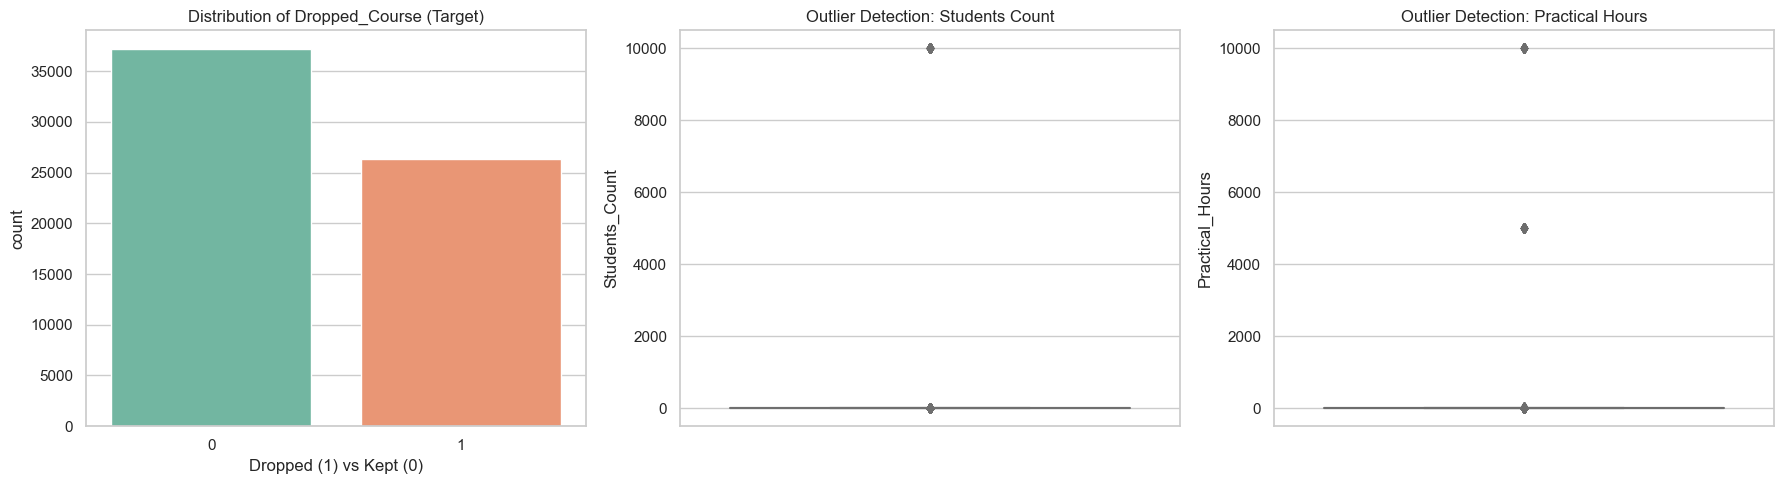

In [136]:
# Create a grid of subplots for initial visual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Variable Distribution
sns.countplot(data=df_train, x='Dropped_Course', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Dropped_Course (Target)')
axes[0].set_xlabel('Dropped (1) vs Kept (0)')

# 2. Boxplot to visualize Students_Count Outliers
sns.boxplot(data=df_train, y='Students_Count', ax=axes[1], color='skyblue')
axes[1].set_title('Outlier Detection: Students Count')

# 3. Boxplot to visualize Practical_Hours Outliers
sns.boxplot(data=df_train, y='Practical_Hours', ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Practical Hours')

plt.tight_layout()
plt.show()

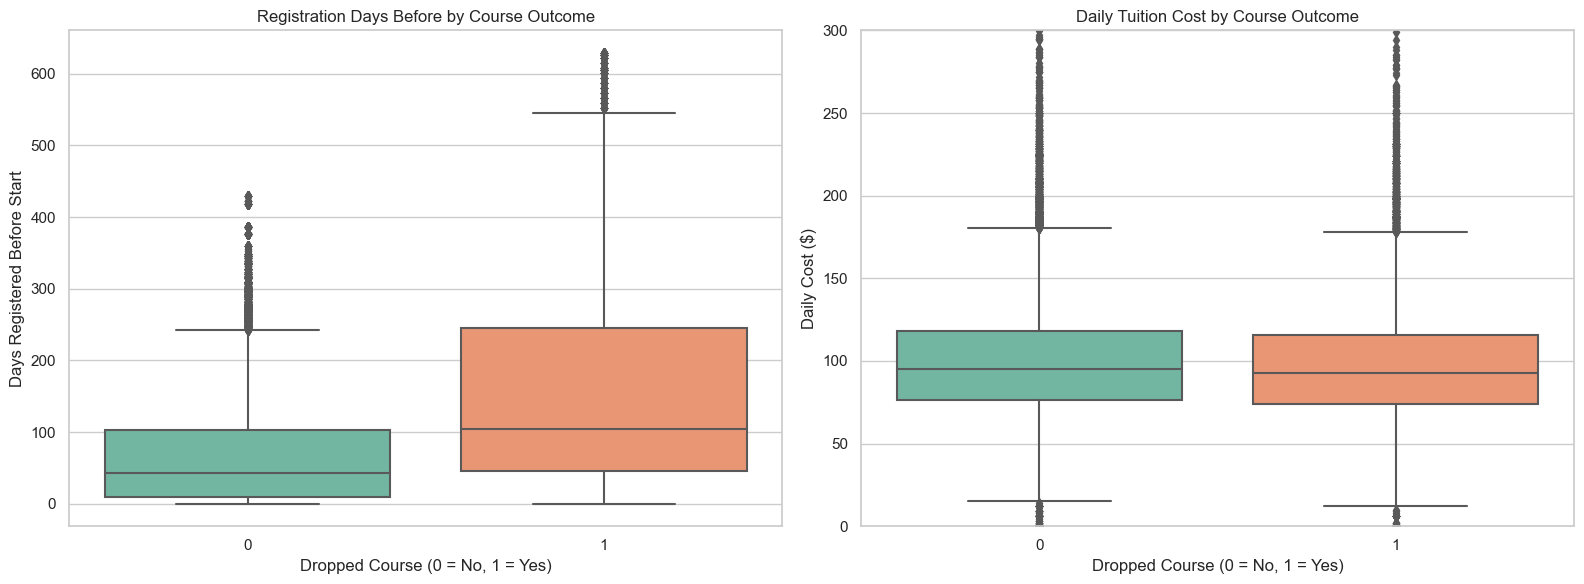

In [137]:
# Create a split boxplot to analyze features against the target variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Registration Days Before split by Dropped_Course
sns.boxplot(data=df_train, x='Dropped_Course', y='Registration_Days_Before', ax=axes[0], palette='Set2')
axes[0].set_title('Registration Days Before by Course Outcome')
axes[0].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[0].set_ylabel('Days Registered Before Start')

# Graph 2: Daily Tuition Cost split by Dropped_Course (Limiting y-axis to focus on the bulk of data)
sns.boxplot(data=df_train, x='Dropped_Course', y='Daily_Tuition_Cost', ax=axes[1], palette='Set2')
axes[1].set_title('Daily Tuition Cost by Course Outcome')
axes[1].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[1].set_ylabel('Daily Cost ($)')
axes[1].set_ylim(0, 300) # limiting to 300 to clear out the 5400 outlier and see the boxes clearly

plt.tight_layout()
plt.show()

#### Insights from Bivariate Boxplot Analysis:

1. **Registration Days Before vs. Course Outcome (Key Discovery):**
   * **Observation:** The plot reveals a strong visual discrepancy between the two groups. The median registration time for clients who eventually canceled (`Dropped_Course = 1`) is substantially higher than for those who attended (`Dropped_Course = 0`). The 75th percentile for the canceled group stretches beyond 250 days, while the non-canceled group is heavily concentrated below 100 days.
   * **Business Logic (The Data Story):** This indicates that **early bookers are far more likely to cancel**. From a business perspective, when an organization reserves a course many months in advance, their internal projects, budget allocations, or training needs are more prone to shift, leading to a cancellation. Conversely, short-notice registrations represent immediate corporate needs and are highly stable.
   * **Feature Engineering Value:** `Registration_Days_Before` is highly likely to be one of the most predictive continuous features for our tree-based models (XGBoost).

2. **Daily Tuition Cost vs. Course Outcome:**
   * **Observation:** The distribution of `Daily_Tuition_Cost` looks remarkably similar across both classes. The medians (around $95), IQRs, and ranges are nearly identical after filtering out the extreme system outliers.
   * **Business Logic:** This suggests that the cost of the training alone does not act as a primary driver for cancellations. Whether a course is cheap or expensive, the cancellation behavior remains relatively uniform.

### 1.3 Correlation Analysis & Feature Interactions
To prevent multicollinearity and understand the linear relationships within our dataset, we compute the Pearson correlation matrix for key numerical features. We then isolate and visualize how each individual feature correlates directly with our target variable (`Dropped_Course`). 

This matrix will provide foundational hints for Feature Selection and Dimensionality Reduction in the next phases.

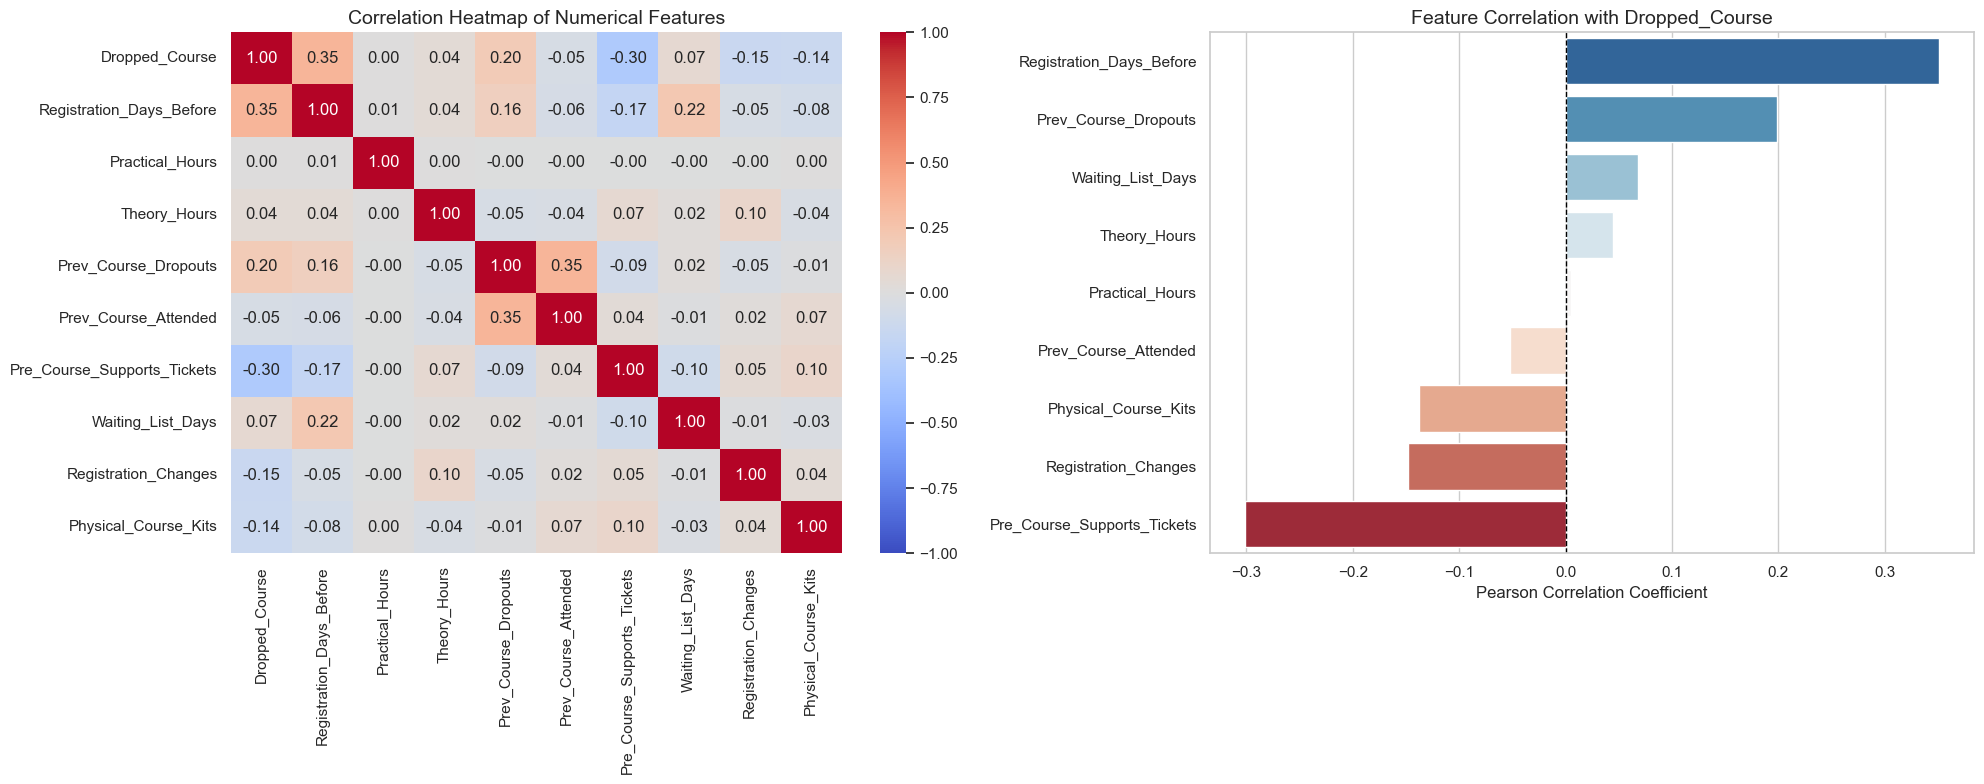

In [138]:
# Select key numerical features for correlation analysis
# (Excluding IDs and heavily distorted features for a cleaner initial look)
corr_features = [
    'Dropped_Course', 'Registration_Days_Before', 'Practical_Hours', 
    'Theory_Hours', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 
    'Pre_Course_Supports_Tickets', 'Waiting_List_Days', 'Registration_Changes',
    'Physical_Course_Kits'
]

# Calculate the Pearson correlation matrix
corr_matrix = df_train[corr_features].corr()

# Set up the matplotlib figure for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('Correlation Heatmap of Numerical Features', fontsize=14)

# 2. Direct Correlation with Target (Sorted)
target_corr = corr_matrix['Dropped_Course'].drop('Dropped_Course').sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='RdBu_r')
axes[1].set_title('Feature Correlation with Dropped_Course', fontsize=14)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

#### Insights from Correlation Analysis:

1. **Pre-Course Support Tickets vs. Cancellations (Critical Discovery):**
   * **Observation:** `Pre_Course_Supports_Tickets` exhibits a notable negative Pearson correlation of **-0.30** with `Dropped_Course`. 
   * **Business Logic:** Counter-intuitively, a higher volume of support tickets before the course starts strongly aligns with a *lower* probability of cancellation. This indicates that clients who actively engage with customer support or IT configuration requests are highly invested in the upcoming training. Their proactive problem-solving reflects strong intent to attend, while silent clients are far more volatile.

2. **Historical Behavior Consistency (`Prev_Course_Dropouts` = +0.20):**
   * **Observation:** There is a positive correlation between past dropouts and current course cancellations. 
   * **Business Logic:** Organizations that have a history of canceling Nova Academy courses in the past are statistically more prone to repeat this behavior ("serial cancelers"). This provides a strong behavioral anchor for our machine learning model.

3. **Registration Changes (`Registration_Changes` = -0.15):**
   * **Observation:** More modifications to the booking details correlate with fewer cancellations. 
   * **Business Logic:** Making changes to the registration implies that the client is actively updating logistics, catering, or seat counts to match their evolving business constraints, rather than completely abandoning the contract.

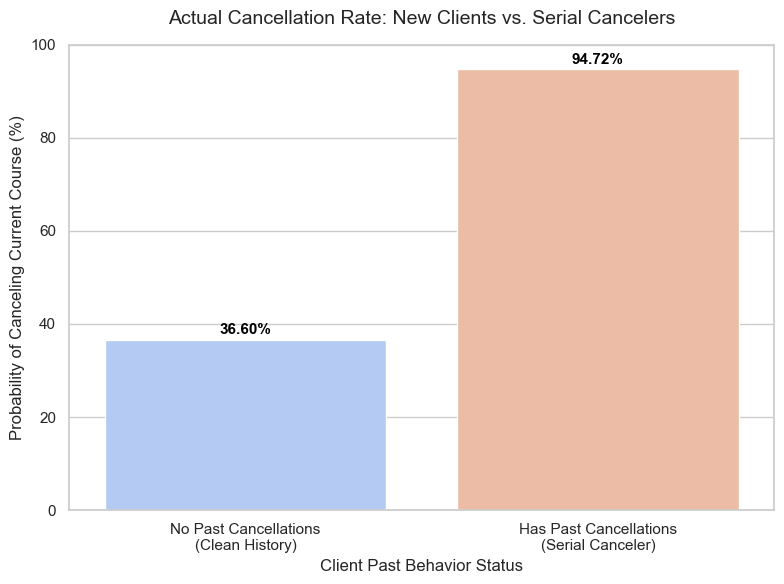

In [139]:
# 1. Create the binary indicator (0 = No past dropouts, 1 = Has past dropouts)
df_train['Had_Past_Cancellations'] = (df_train['Prev_Course_Dropouts'] > 0).astype(int)

# 2. Calculate the actual cancellation rate (mean of Dropped_Course * 100)
cancellation_rates = df_train.groupby('Had_Past_Cancellations')['Dropped_Course'].mean() * 100

# 3. Plotting the results
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=cancellation_rates.index, y=cancellation_rates.values, palette='coolwarm')

# Visual styling
plt.title('Actual Cancellation Rate: New Clients vs. Serial Cancelers', fontsize=14, pad=15)
plt.xlabel('Client Past Behavior Status', fontsize=12)
plt.ylabel('Probability of Canceling Current Course (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Past Cancellations\n(Clean History)', 'Has Past Cancellations\n(Serial Canceler)'])
plt.ylim(0, 100)

# Adding percentage labels on top of the bars for ultimate clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 2), 
                ha='center', va='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

#### 1.4 The "Serial Canceler" Effect

* **The Discovery:** While our initial correlation matrix showed a moderate positive Pearson correlation (+0.20) between `Prev_Course_Dropouts` and `Dropped_Course`, a percentage-based segmentation reveals a staggering behavioral anchor. 
* **The Numbers:** * Clients with a **clean history** (no past dropouts) have a baseline cancellation rate of **36.60%**.
  * Clients with **at least one past dropout** exhibit a near-certain cancellation rate of **94.72%**.

#### Business & Modeling Implications:
1. **Predictive Power:** This single binary feature (`Had_Past_Cancellations`) acts as an incredibly strong separator. Our tree-based models (XGBoost) will heavily rely on this branch to isolate high-risk corporate accounts.
2. **Operational Risk Management:** For Nova Academy's operations team, any incoming reservation from an account with a history of cancellations should trigger immediate mitigation protocols (e.g., non-refundable deposits or holding off on cloud-lab environment provisioning) to eliminate wasted upfront costs.

### 1.5 Data Cleaning: Converting System Anomalies to Missing Values (NaN)
Before applying imputation techniques, we must isolate the business-logic violations and system placeholders discovered during the EDA phase. Instead of dropping these rows—which would prevent our pipeline from processing similar anomalies if they appear in the test set—we systematically replace them with `np.nan`.

**Anomalies Handled:**
* `Students_Count` == 9999 (System placeholder)
* `Practical_Hours` == 10000 (Data entry error)
* `Practical_Hours` < 0 (Logical violation)
* `Practical_Hours` ==0 && `Practical Hours`==0  (a course with zero hours cant exist)

In [140]:
# Create a copy of the dataframe to keep the raw data intact
df_cleaned=df_train.copy()

# 1. Handle Students_Count placeholder (9999)
df_cleaned['Students_Count'] = df_cleaned['Students_Count'].replace(9999, np.nan)

# 2. Handle Practical_Hours extreme outlier (10000)
df_cleaned['Practical_Hours'] = df_cleaned['Practical_Hours'].replace(10000, np.nan)

# 3. Handle Practical_Hours negative values (< 0)
df_cleaned.loc[df_cleaned['Practical_Hours'] < 0, 'Practical_Hours'] = np.nan

#4. Handle Daily_Tuition_Cost extreme outlier (> 1000)
df_cleaned.loc[df_cleaned['Daily_Tuition_Cost'] > 1000, 'Daily_Tuition_Cost'] = np.nan

#5 Locate the ghost courses and set their hours to NaN so the median imputer can fix them
ghost_courses_mask = (df_cleaned['Practical_Hours'] == 0) & (df_cleaned['Theory_Hours'] == 0)
df_cleaned.loc[ghost_courses_mask, ['Practical_Hours', 'Theory_Hours']] = np.nan

# Verification: Updated to include all cleaned continuous columns
# List of non-categorical (numerical) features that act as discrete counters or metrics
discrete_numerical_cols = [
    'Professionals_Count', 'Students_Count', 'Observers_Count', 
    'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 
    'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes','Practical_Hours','Theory_Hours', 'Daily_Tuition_Cost'
]

print("=== Unique Values in Discrete Numerical Columns (Sorted) ===")
for col in discrete_numerical_cols:
    # Get unique values, drop NaN for clean view, and sort them
    unique_vals = sorted(df_cleaned[col].dropna().unique())
    print(f"\nUnique keys for {col}:")
    print(unique_vals)

=== Unique Values in Discrete Numerical Columns (Sorted) ===

Unique keys for Professionals_Count:
[0, 1, 2, 3, 4]

Unique keys for Students_Count:
[0.0, 1.0, 2.0, 3.0]

Unique keys for Observers_Count:
[0, 1, 2, 9, 10]

Unique keys for Prev_Course_Dropouts:
[0, 1, 2, 3, 4, 5, 6, 11, 13, 21]

Unique keys for Prev_Course_Attended:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]

Unique keys for Pre_Course_Supports_Tickets:
[0, 1, 2, 3, 4, 5]

Unique keys for Physical_Course_Kits:
[0.0, 1.0, 2.0, 3.0]

Unique keys for Waiting_List_Days:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 27, 28, 30, 31, 32, 33, 34, 35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 68, 69, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 8

### Data Preparation / Preprocessing
* outlier remoival 
* filling missing values
* dimesionality reduction
* Data transformation / normalization

### 1.7 Categorical Data Standardization & Punctuation Removal
To completely eliminate "Dirty Categorical Data," we applied a strict Regular Expression (Regex) pipeline across all text-based variables. This pipeline forces lowercase uniformity, strips trailing whitespaces, and systematically strips out unwanted punctuation marks (e.g., '!', '?', or special characters) that could cause formatting fragmentation. Finally, any corrupt or empty strings are mapped directly to a unified `'unknown'` token.

In [141]:
import re

# List of all categorical columns to clean thoroughly
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

for col in all_categorical_cols:
    if col in df_cleaned.columns:
    
        df_cleaned[col] = df_cleaned[col].fillna('unknown')
        
        df_cleaned[col] = df_cleaned[col].astype(str).str.lower().str.strip()
        
        df_cleaned[col] = df_cleaned[col].str.replace(r'[^\w\s]', '', regex=True).str.strip()
        
        placeholders = ['', ' ', '?', 'nan', 'none', 'null', 'missing']
        df_cleaned[col] = df_cleaned[col].replace(placeholders, 'unknown')

# Verify the final clean state
# List of all categorical (text-based) columns
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

print("=== Unique Values in Categorical Columns ===")
for col in all_categorical_cols:
    unique_vals = df_cleaned[col].unique()
    print(f"\nClean keys for '{col}' ({len(unique_vals)} total):")
    print(list(unique_vals))

=== Unique Values in Categorical Columns ===

Clean keys for 'Origin_Country' (155 total):
['prt', 'unknown', 'ita', 'bra', 'esp', 'nld', 'gbr', 'deu', 'fra', 'rou', 'swe', 'aut', 'bel', 'ago', 'che', 'nor', 'rus', 'isr', 'pol', 'irl', 'bgr', 'usa', 'chn', 'dza', 'mar', 'aus', 'tun', 'moz', 'mex', 'dnk', 'grc', 'col', 'lux', 'cn', 'lva', 'fin', 'hrv', 'stp', 'ukr', 'ven', 'irn', 'twn', 'kor', 'tur', 'blr', 'jpn', 'cze', 'kaz', 'hun', 'cpv', 'aze', 'lbn', 'cri', 'arg', 'nzl', 'ind', 'idn', 'ltu', 'svk', 'srb', 'svn', 'cmr', 'egy', 'lie', 'sau', 'mys', 'mmr', 'chl', 'irq', 'sgp', 'dom', 'pan', 'sen', 'per', 'jor', 'zaf', 'lka', 'kna', 'tha', 'geo', 'kwt', 'tmp', 'alb', 'eth', 'mus', 'ecu', 'phl', 'are', 'omn', 'bfa', 'and', 'arm', 'ken', 'hnd', 'mco', 'nga', 'gnb', 'lby', 'rwa', 'est', 'pak', 'tza', 'gib', 'zmb', 'qat', 'khm', 'hkg', 'bgd', 'mli', 'isl', 'uzb', 'bih', 'bhr', 'ury', 'nam', 'bol', 'imn', 'cyp', 'tjk', 'mdv', 'mlt', 'nic', 'jam', 'syc', 'pry', 'brb', 'abw', 'ggy', 'aia', 's

#### 1.8 Categorical Data Imputation Strategy
For text-based, categorical features (`Origin_Country`, `Catering_Package`, `Welcome_Gift_Type`, `Requested_Lab_Config`, `Assigned_Lab_Config`, `Enrollment_Type`, `Lanyard_Color`, `Client_Category`, `Submission_Source`, `Payment_Terms`), we avoided using the standard statistical mode (most frequent value). Instead, we implemented a **string-standardization and explicit placeholder strategy**:

1. **Text Normalization & Cleaning:** All categorical fields were converted to lowercase, stripped of leading/trailing whitespaces, and cleared of special characters/punctuation using Regex to ensure structural uniformity.
2. **Explicit 'unknown' Assignment:** Standard statistical missing values (`NaN`), empty strings, and ambiguous placeholders (such as `'nan'`, `'none'`, `'null'`, `'?'`) were unified and replaced with a single explicit string: `'unknown'`.
3. **Machine Learning Logic:** Rather than artificially inflating the dataset's most dominant categories, treating missing data as its own separate `'unknown'` state allows our tree-based models to treat "missingness" as an independent, informative feature. This preserves the original data distribution and lets the model discover whether hidden correlations exist between incomplete registration forms and the target behavior (course cancellations).

As a result, the categorical missing data count stands at **0**, and all underlying unrecorded values are safely encapsulated within the `'unknown'` class.

Checking for NaN Vals in each feature

In [142]:
df_analysis = df_cleaned.copy()

numerical_cols = df_analysis.select_dtypes(include=['number']).columns
categorical_cols = df_analysis.select_dtypes(include=['object', 'category']).columns

numeric_nans = df_analysis[numerical_cols].isna().sum()
if 'Agent_ID' in numeric_nans.index:
    numeric_nans = numeric_nans.drop('Agent_ID')

numeric_summary = pd.DataFrame({'NaN Counts': numeric_nans})
numeric_summary = numeric_summary[numeric_summary['NaN Counts'] > 0]

cat_unknown = pd.Series(0, index=categorical_cols)
for col in categorical_cols:
    cat_unknown[col] = (df_analysis[col] == 'unknown').sum()

categorical_summary = pd.DataFrame({'Unknown Counts': cat_unknown})
categorical_summary = categorical_summary[categorical_summary['Unknown Counts'] > 0]

print("==================================================")
print("    NUMERICAL FEATURES MISSING DATA (NaNs)      ")
print("==================================================")
if not numeric_summary.empty:
    print(numeric_summary.sort_values(by='NaN Counts', ascending=False))
else:
    print("✓ Clean! Zero NaNs found in target numerical features.")

print("\n")

print("==================================================")
print("    CATEGORICAL FEATURES (Unknown Counts)      ")
print("==================================================")
if not categorical_summary.empty:
    print(categorical_summary.sort_values(by='Unknown Counts', ascending=False))
else:
    print("✓ Clean! Zero unknown values found in categorical features.")
print("==================================================")

    NUMERICAL FEATURES MISSING DATA (NaNs)      
                          NaN Counts
Company_ID                     60344
Registration_Days_Before        2666
Physical_Course_Kits            1040
Practical_Hours                  396
Theory_Hours                     309
Daily_Tuition_Cost                80
Students_Count                    59


    CATEGORICAL FEATURES (Unknown Counts)      
                      Unknown Counts
Requested_Lab_Config            1736
Submission_Source               1014
Payment_Terms                   1006
Enrollment_Type                  719
Origin_Country                   557
Catering_Package                 407
Client_Category                    2


#### 1.9 Differentiated Numerical Imputation Strategy
Instead of blindly applying a global median to all numerical fields, we applied a business-driven split strategy:
1. **Median Imputer:** Applied to skewed, continuous variables (`Registration_Days_Before`, `Daily_Tuition_Cost`, `Physical_Course_Kits`) to remain robust against valid long-tail distributions.
2. **Constant Zero Imputer:** Applied specifically to `Students_Count`. Rather than assuming a missing value represents a generic median class size, business logic dictates that an omission likely implies zero students were enrolled for that specific iteration (e.g., a technical-only or observer-only setup). This preserves structural integrity and allows clean integer casting without synthetic inflation.

In [143]:
median_numerical_cols = ['Registration_Days_Before', 'Physical_Course_Kits', 'Daily_Tuition_Cost', 'Practical_Hours', 'Theory_Hours']

median_imputer = SimpleImputer(strategy='median')
zero_imputer = SimpleImputer(strategy='constant', fill_value=0) # מילוי קבוע ב-0 לסטודנטים

df_cleaned[median_numerical_cols] = median_imputer.fit_transform(df_cleaned[median_numerical_cols])
df_cleaned[['Students_Count']] = zero_imputer.fit_transform(df_cleaned[['Students_Count']])

df_cleaned['Students_Count'] = df_cleaned['Students_Count'].astype(int)
df_cleaned['Physical_Course_Kits'] = df_cleaned['Physical_Course_Kits'].astype(int)

print(f"✓ Pipeline complete with Business Logic Zero-Imputation!")
print(f"✓ Final df_cleaned shape: {df_cleaned.shape}")
print(f"✓ Total remaining NaNs : {df_cleaned.isnull().sum().sum()}")

✓ Pipeline complete with Business Logic Zero-Imputation!
✓ Final df_cleaned shape: (63464, 30)
✓ Total remaining NaNs : 71517


**Categorial Features - fill unknown values strategy:**

1.**Agent_ID** we decided to fill the `Agent_ID` missing values with -1 Instead of corrupting the data by filling missing agent values with a median (e.g., attributing 11,173 courses to a random salesperson), we filled these missing entries with `-1`. In our domain logic, a missing agent ID strongly signifies an independent registration. Assigning `-1` isolates these entries into a unique, highly informative category.
2.**Origin_Country** - most common 
3.**Catering_Package** - standart (if didnt chose assignes standart)
4.Requested_Lab_Config - standart
5.Client_Category - most common
6. Submmision_Source - most common
7. Payment_Terms - most common
8. Enrollment_Type - most common

In [144]:
df_cleaned['Agent_ID'] = df_cleaned['Agent_ID'].fillna(-1).astype(int)
df_cleaned = df_cleaned.replace(['unknown'])
 
df_cleaned['Origin_Country'] = df_cleaned['Origin_Country'].fillna(df_cleaned['Origin_Country'].mode()[0])
 
df_cleaned['Catering_Package'] = df_cleaned['Catering_Package'].fillna('Standard (Coffee Only)')
 
df_cleaned['Requested_Lab_Config'] = df_cleaned['Requested_Lab_Config'].fillna('Standard PC (Windows)')
 
df_cleaned['Client_Category'] = df_cleaned['Client_Category'].fillna(df_cleaned['Client_Category'].mode()[0])

df_cleaned['Submission_Source'] = df_cleaned['Submission_Source'].fillna(df_cleaned['Submission_Source'].mode()[0])
 
df_cleaned['Payment_Terms'] = df_cleaned['Payment_Terms'].fillna(df_cleaned['Payment_Terms'].mode()[0])
 
df_cleaned['Agent_ID'] = df_cleaned['Agent_ID'].fillna(-1)
 
df_cleaned['Enrollment_Type'] = df_cleaned['Enrollment_Type'].fillna('General Admission')
 
print(df_cleaned[[
    'Origin_Country', 'Catering_Package', 'Requested_Lab_Config', 
    'Client_Category', 'Submission_Source', 'Payment_Terms', 
    'Agent_ID', 'Enrollment_Type'
]].isnull().sum())


Origin_Country          0
Catering_Package        0
Requested_Lab_Config    0
Client_Category         0
Submission_Source       0
Payment_Terms           0
Agent_ID                0
Enrollment_Type         0
dtype: int64


------------------------------------------------------------------------------------------

## Part B: Feature Engineering
* Dimensionality reduction 
* Data transformation / normalization  
* Feature engineering 

***🗑️ Dimensionality reduction - Feature Dropping:*** 
* Company_ID - The `Company_ID` feature was dropped because it contains ~95% missing values (60,344 NaNs), meaning any imputation would introduce severe statistical noise into our model.

* Practical_hours - due to zero correlation with the target (correlation matrix at part A)

* Client_ID - a random client ID wont give us useful information

* Lanyard_Color - as shown below for Lanyard_Color feature the dropout rate (1) remains virtually identical (around 41.5%) across all colors, proving it has zero predictive power or correlation with the target variable.



In [145]:
print(pd.crosstab(df_cleaned['Lanyard_Color'], df_cleaned['Dropped_Course'], normalize='index') * 100)

Dropped_Course          0          1
Lanyard_Color                       
black           58.541681  41.458319
blue            58.641236  41.358764
green           58.314937  41.685063
orange          58.344790  41.655210
red             58.409786  41.590214


In [146]:
df_cleaned = df_cleaned.drop(columns=['Company_ID'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Practical_Hours'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Client_ID'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Lanyard_Color'], errors='ignore')

print(f"✓ Columns dropped successfully! Remaining columns count: {len(df_cleaned.columns)}")

✓ Columns dropped successfully! Remaining columns count: 26


## Data transformation 

### Data normalization

In [176]:
from sklearn.preprocessing import StandardScaler

# 1. Define Target and Features ONLY for your current training data
X_train = df_encoded.drop(columns=['Dropped_Course'])
y_train = df_encoded['Dropped_Course']

# 2. Final verified list of continuous numerical features for scaling
numeric_features = [
    'Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours',  
    'Registration_Days_Before', 'Prev_Course_Dropouts', 'Pre_Course_Supports_Tickets', 
    'Waiting_List_Days', 'Daily_Tuition_Cost', 'Physical_Course_Kits',      
    'Registration_Changes', 'Prev_Course_Attended', 'Dropout_Ratio', 'Support_Ticket_per_Course'  
]

# 3. Filter list to ensure columns actually exist in X_train
numeric_features = [col for col in numeric_features if col in X_train.columns]

# 4. Initialize the scaler and fit_transform ONLY X_train
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

print(f"[V] X_train defined and normalized. Current shape: {X_train.shape}")

[V] X_train defined and normalized. Current shape: (63464, 49)


### OneHotEncoding / Dummy variables ###

Performed OneHotEncoding to the following features: 'Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 'Client_Category', 'Submission_Source', 'Payment_Terms'
the other features will be handled seperatly.

In [ ]:

from sklearn.preprocessing import OneHotEncoder

cleaned_categorial_cols = ['Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 'Client_Category', 'Submission_Source', 'Payment_Terms'] 
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_cleaned[cleaned_categorial_cols])
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(cleaned_categorial_cols),
    index=df_cleaned.index
)
df_encoded = df_cleaned.drop(columns=cleaned_categorial_cols).join(encoded_df)
print(df_encoded.columns.tolist())


['Professionals_Count', 'Students_Count', 'Observers_Count', 'Theory_Hours', 'Registration_Days_Before', 'Origin_Country', 'Requested_Lab_Config', 'Assigned_Lab_Config', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes', 'Returning_Client', 'Agent_ID', 'Daily_Tuition_Cost', 'Dropped_Course', 'Had_Past_Cancellations', 'Registration_Window', 'Has_Registration_Changes', 'Is_Digital_Registration', 'Support_Ticket_per_Course', 'High_Support_Engagement', 'Reg_Within_7_Days', 'Reg_Over_90_Days_Before', 'Is_Serial_Canceler', 'Dropout_Ratio', 'Course_Start_Month', 'Course_Start_Quarter', 'Course_Start_DayOfWeek', 'Catering_Package_lunch included', 'Catering_Package_no food plan', 'Catering_Package_standard coffee only', 'Welcome_Gift_Type_portable charger', 'Welcome_Gift_Type_usb drive', 'Welcome_Gift_Type_water bottle', 'Enrollment_Type_contractual agreement', 'Enrollment_Type_general admission', '

### Origin_Country investigation and startegy

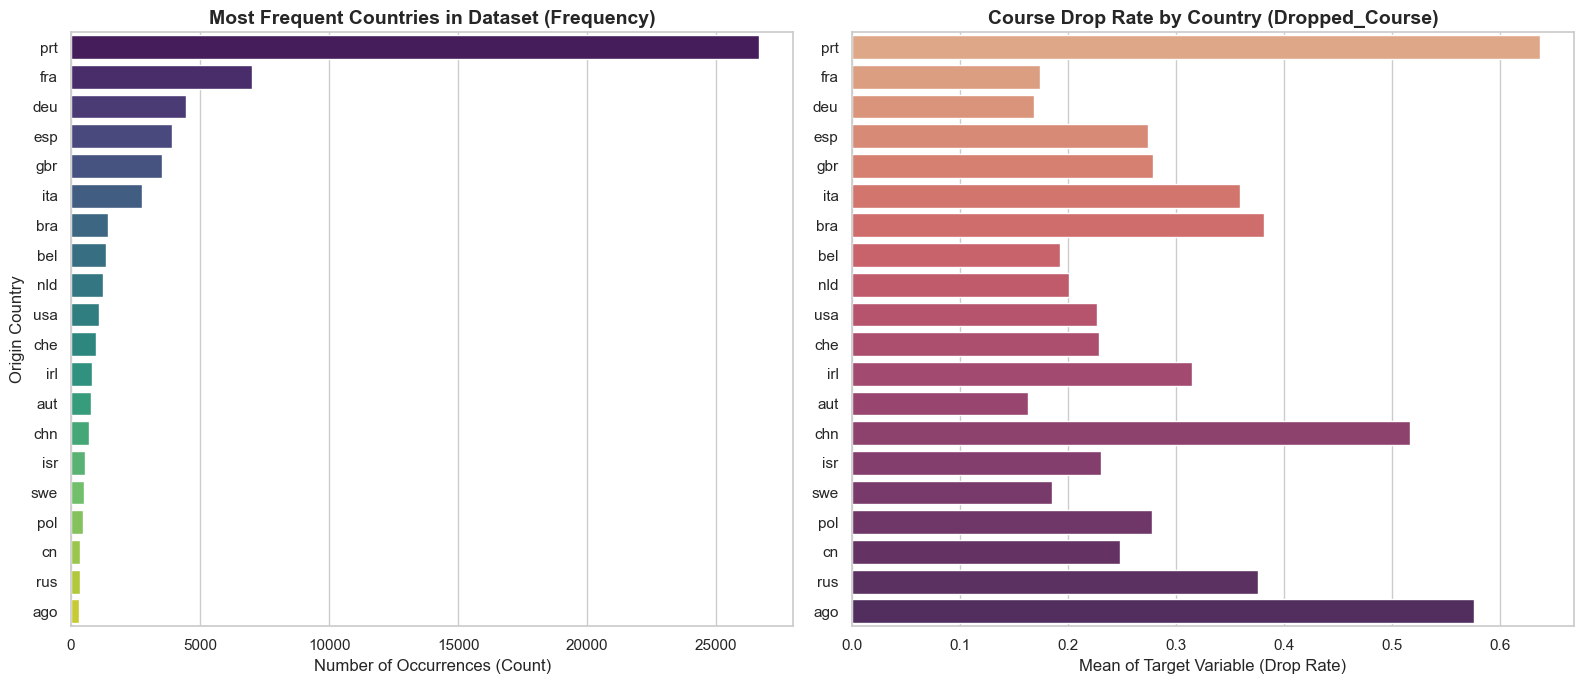

In [161]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Get the top 20 most frequent countries to keep the visualization clean
top_countries = df_encoded['Origin_Country'].value_counts().head(20).index
df_filtered = df_encoded[df_encoded['Origin_Country'].isin(top_countries)]
# --- Plot 1: Country Frequencies (Frequency Encoding Analysis) ---

sns.countplot(

    data=df_filtered,
    y='Origin_Country',
    order=top_countries,
    ax=axes[0],
    palette='viridis'
)

axes[0].set_title('Most Frequent Countries in Dataset (Frequency)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Occurrences (Count)')
axes[0].set_ylabel('Origin Country')
 
country_target_means = df_filtered.groupby('Origin_Country')['Dropped_Course'].mean().loc[top_countries]
sns.barplot(
    x=country_target_means.values,
    y=country_target_means.index,
    ax=axes[1],
    palette='flare'
)

axes[1].set_title('Course Drop Rate by Country (Dropped_Course)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean of Target Variable (Drop Rate)')
axes[1].set_ylabel('') 

plt.tight_layout()

plt.show()
 

### 1. Key Findings
* **Frequency:** The data features a severe "long-tail" distribution. A single country (`prt`) dominates with >25k rows, while most other countries have extremely low representation.
* **Target Variance:** The target variable (`Dropped_Course`) varies drastically by country—ranging from nearly **65%** (high risk for `prt`) to under **20%** (low risk for `aut`, `swe`).
 
### 2. Strategy: Target Encoding with Smoothing
We selected **Target Encoding** because country of origin is a powerful predictor of drop rates. However, to eliminate the risk of **overfitting on minority countries** (small sample sizes), we implemented **Empirical Bayesian Smoothing**.
 
#### How Smoothing Works:
* **High-volume countries (e.g., `prt`):** The encoder relies heavily on the country's actual drop rate.
* **Low-volume countries:** The encoder distrusts the small sample size and pulls ("smoothes") the value toward the **global baseline average** of the entire dataset.

In [164]:
global_mean = df_encoded['Dropped_Course'].mean()
stats = df_encoded.groupby('Origin_Country')['Dropped_Course'].agg(['mean', 'count'])
smoothing_factor = 50.0
stats['weight'] = stats['count'] / (stats['count'] + smoothing_factor)
stats['encoded_value'] = (stats['weight'] * stats['mean']) + ((1 - stats['weight']) * global_mean)
df_encoded['Origin_Country'] = df_encoded['Origin_Country'].map(stats['encoded_value'])
 

 ### New Feature Brainstorming (investigation)

#### Days registration before feature EDA

--- טבלת סיכויי ביטול והצלחה לפי חלונות זמן ---
Registration_Window  Total_Registrations  Cancellation_Rate  Success_Rate
       Same Day (0)                 2610           0.082375      0.917625
           1-3 Days                 3416           0.123536      0.876464
           4-7 Days                 3041           0.153897      0.846103
          8-14 Days                 3737           0.251271      0.748729
         15-30 Days                 6335           0.339384      0.660616
         1-2 Months                 9953           0.387923      0.612077
         2-3 Months                10045           0.417621      0.582379
          3+ Months                24327           0.577506      0.422494

[V] הגרף registration_time_eda.png נשמר בהצלחה!

--- נקודות החיתוך (Thresholds) האופטימליות שמצא האלגוריתם ---
|--- Registration_Days_Before <= 257.50
|   |--- Registration_Days_Before <= 17.50
|   |   |--- class: 0
|   |--- Registration_Days_Before >  17.50
|   |   |--- class: 0
|---

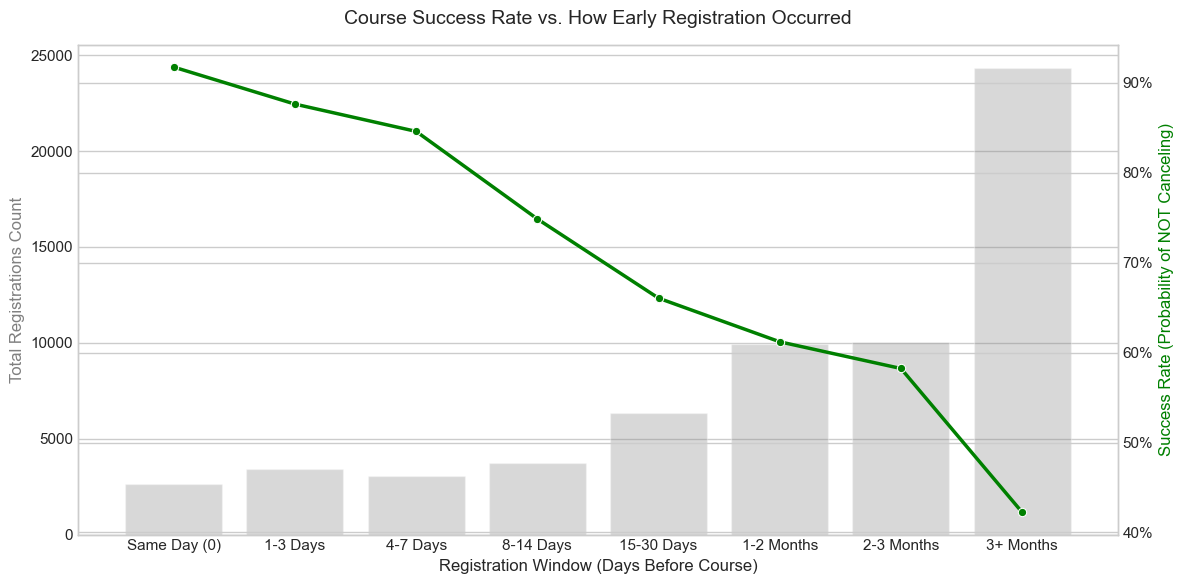

In [148]:
from sklearn.tree import DecisionTreeClassifier, export_text

bins = [-1, 0, 3, 7, 14, 30, 60, 90, np.inf]
labels = ['Same Day (0)', '1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '1-2 Months', '2-3 Months', '3+ Months']

df_cleaned['Registration_Window'] = pd.cut(df_cleaned['Registration_Days_Before'], bins=bins, labels=labels)

eda_summary = df_cleaned.groupby('Registration_Window', observed=False).agg(
    Total_Registrations=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

eda_summary['Success_Rate'] = 1 - eda_summary['Cancellation_Rate']

print("--- טבלת סיכויי ביטול והצלחה לפי חלונות זמן ---")
print(eda_summary.to_string(index=False))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=eda_summary, x='Registration_Window', y='Total_Registrations', alpha=0.3, color='gray', ax=ax1)
ax1.set_ylabel('Total Registrations Count', color='gray')
ax1.set_xlabel('Registration Window (Days Before Course)')

ax2 = ax1.twinx()
sns.lineplot(data=eda_summary, x='Registration_Window', y='Success_Rate', marker='o', color='green', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Success Rate (Probability of NOT Canceling)', color='green')
ax2.yaxis.set_major_formatter(lambda x, pos: f'{x*100:.0f}%')

plt.title('Course Success Rate vs. How Early Registration Occurred', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('registration_time_eda.png')
print("\n[V] הגרף registration_time_eda.png נשמר בהצלחה!")

df_tree = df_cleaned[['Registration_Days_Before', 'Dropped_Course']].dropna()

X = df_tree[['Registration_Days_Before']]
y = df_tree['Dropped_Course']

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)

tree_rules = export_text(tree, feature_names=['Registration_Days_Before'])
print("\n--- נקודות החיתוך (Thresholds) האופטימליות שמצא האלגוריתם ---")
print(tree_rules)

Pearson Correlation Coefficient: -0.1950

          Status  Total_Count  Cancellation_Rate
  No Changes (0)        55478           0.450845
Had Changes (1+)         7986           0.161157


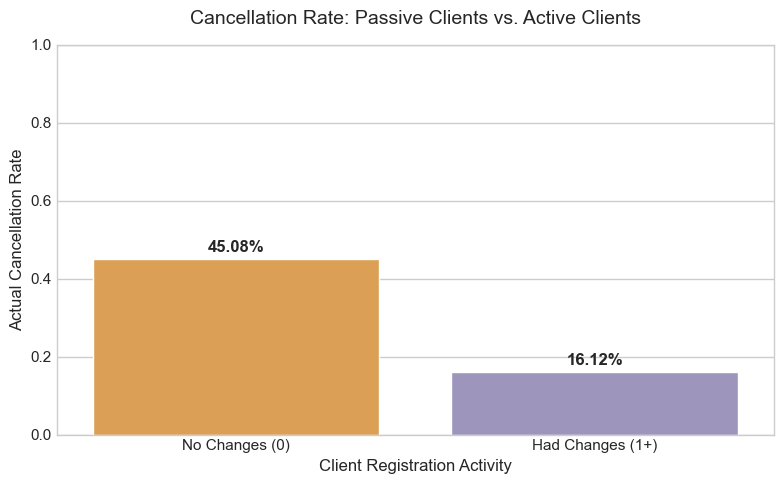

In [149]:

# 1. Create the binary feature
df_cleaned['Has_Registration_Changes'] = (df_cleaned['Registration_Changes'] > 0).astype(int)

# 2. Calculate Pearson correlation coefficient
binary_corr = df_cleaned['Has_Registration_Changes'].corr(df_cleaned['Dropped_Course'])
print(f"Pearson Correlation Coefficient: {binary_corr:.4f}\n")

# 3. Calculate actual cancellation rates
summary = df_cleaned.groupby('Has_Registration_Changes').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Status'] = summary['Has_Registration_Changes'].map({0: 'No Changes (0)', 1: 'Had Changes (1+)'})

print(summary[['Status', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))

# 4. Generate the EDA plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=summary, x='Status', y='Cancellation_Rate', palette=['#f1a340', '#998ec3'])

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Passive Clients vs. Active Clients', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Client Registration Activity')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('has_changes_binary_eda.png')

agentID

Pearson Correlation Coefficient: -0.0744

                  Registration_Type  Total_Count  Cancellation_Rate
        Via Agent (Agent_ID exists)        52291           0.431336
Digital / Self-Reg (Agent_ID == -1)        11173           0.335094


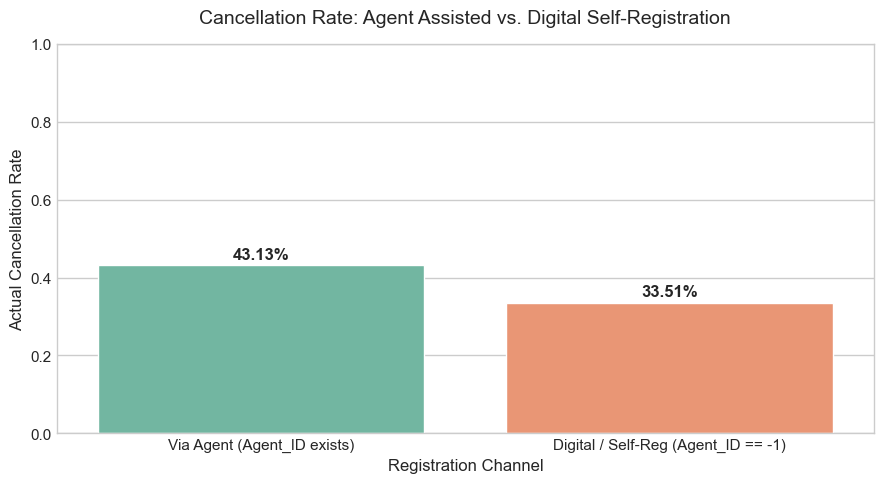

In [150]:


# 1. Create the binary feature: 1 if Agent_ID is -1 (Digital/Independent), 0 if it was a real Agent
df_cleaned['Is_Digital_Registration'] = (df_cleaned['Agent_ID'] == -1).astype(int)

# 2. Calculate Pearson correlation coefficient
digital_corr = df_cleaned['Is_Digital_Registration'].corr(df_cleaned['Dropped_Course'])
print(f"Pearson Correlation Coefficient: {digital_corr:.4f}\n")

# 3. Calculate actual cancellation rates
summary = df_cleaned.groupby('Is_Digital_Registration').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Registration_Type'] = summary['Is_Digital_Registration'].map({0: 'Via Agent (Agent_ID exists)', 1: 'Digital / Self-Reg (Agent_ID == -1)'})

print(summary[['Registration_Type', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))

# 4. Generate the EDA plot
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=summary, x='Registration_Type', y='Cancellation_Rate', palette='Set2')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Agent Assisted vs. Digital Self-Registration', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Registration Channel')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('digital_registration_eda.png')

Continuous Feature Correlation: -0.3016

Binary Feature Correlation (Threshold > 1.00): -0.1655

                  Status  Total_Count  Cancellation_Rate
Low/Normal Tickets Ratio        56258           0.443564
      High Tickets Ratio         7206           0.186650


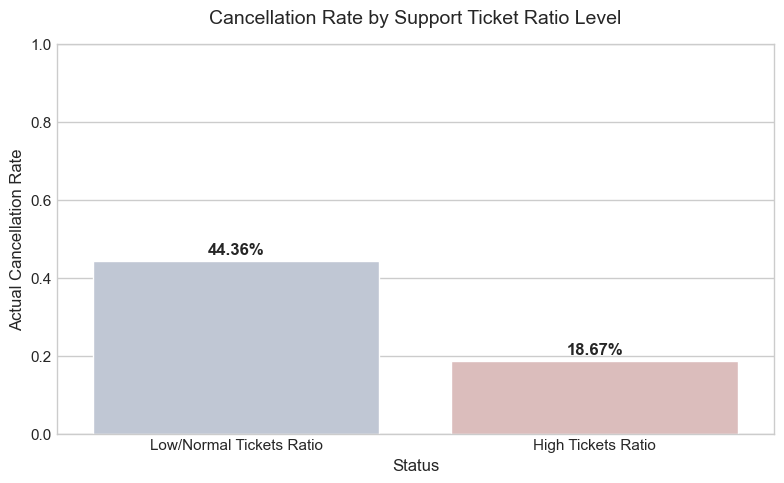

In [151]:

# 1. Calculate the continuous feature
total_past_courses = df_cleaned['Prev_Course_Dropouts'] + df_cleaned['Prev_Course_Attended']
df_cleaned['Support_Ticket_per_Course'] = df_cleaned['Pre_Course_Supports_Tickets'] / (total_past_courses + 1)

# 2. Calculate continuous correlation
continuous_corr = df_cleaned['Support_Ticket_per_Course'].corr(df_cleaned['Dropped_Course'])
print(f"Continuous Feature Correlation: {continuous_corr:.4f}\n")

# 3. Create a Binary Version: 1 if tickets per course is higher than the median (of those who have tickets)
tickets_mesh = df_cleaned[df_cleaned['Pre_Course_Supports_Tickets'] > 0]['Support_Ticket_per_Course']
median_threshold = tickets_mesh.median() if len(tickets_mesh) > 0 else 0.5

df_cleaned['High_Support_Engagement'] = (df_cleaned['Support_Ticket_per_Course'] > median_threshold).astype(int)

# 4. Calculate binary correlation
binary_corr = df_cleaned['High_Support_Engagement'].corr(df_cleaned['Dropped_Course'])
print(f"Binary Feature Correlation (Threshold > {median_threshold:.2f}): {binary_corr:.4f}\n")

# 5. Aggregate for visual comparison
summary = df_cleaned.groupby('High_Support_Engagement').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Status'] = summary['High_Support_Engagement'].map({0: 'Low/Normal Tickets Ratio', 1: 'High Tickets Ratio'})

print(summary[['Status', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))

# 6. Plot the comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=summary, x='Status', y='Cancellation_Rate', palette='vlag')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate by Support Ticket Ratio Level', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('support_ticket_ratio_eda.png')

#### Dropout_Ratio investigation 

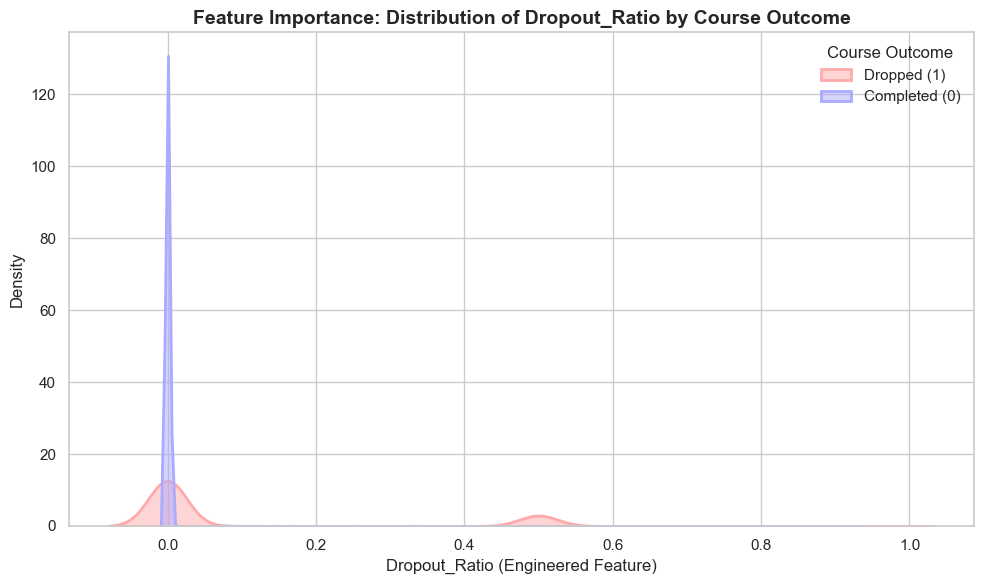

In [177]:
import matplotlib.pyplot as plt

import seaborn as sns
 
# Set style and create plot

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
 
# Plot the distribution of Dropout_Ratio for both classes

sns.kdeplot(

    data=df_cleaned, 

    x='Dropout_Ratio', 

    hue='Dropped_Course', 

    fill=True, 

    common_norm=False, 

    palette='bwr', 

    alpha=0.5, 

    linewidth=2

)
 
# Configuration and English Labels

plt.title('Feature Importance: Distribution of Dropout_Ratio by Course Outcome', fontsize=14, fontweight='bold')

plt.xlabel('Dropout_Ratio (Engineered Feature)', fontsize=12)

plt.ylabel('Density', fontsize=12)
 
# Customizing the legend to be professional

plt.legend(title='Course Outcome', labels=['Dropped (1)', 'Completed (0)'])
 
plt.tight_layout()

plt.show()
 

In [152]:
# 1. Registration Time Features
df_cleaned['Reg_Within_7_Days'] = (df_cleaned['Registration_Days_Before'] <= 7).astype(int)
df_cleaned['Reg_Over_90_Days_Before'] = (df_cleaned['Registration_Days_Before'] >= 90).astype(int)

# 2. Client Activity & Missingness Features
df_cleaned['Has_Registration_Changes'] = (df_cleaned['Registration_Changes'] > 0).astype(int)
df_cleaned['Is_Digital_Registration'] = (df_cleaned['Agent_ID'] == -1).astype(int)
df_cleaned['Is_Serial_Canceler'] = (df_cleaned['Prev_Course_Dropouts'] > 0).astype(int)

# 3. Historical Performance Ratios (with smoothing to prevent division by zero)
df_cleaned['Dropout_Ratio'] = df_cleaned['Prev_Course_Dropouts'] / (df_cleaned['Prev_Course_Dropouts'] + df_cleaned['Prev_Course_Attended'] + 1)
total_past_courses = df_cleaned['Prev_Course_Dropouts'] + df_cleaned['Prev_Course_Attended']

df_cleaned['Support_Ticket_per_Course'] = df_cleaned['Pre_Course_Supports_Tickets'] / (total_past_courses + 1)

df_cleaned.head(5)

,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,Welcome_Gift_Type,Requested_Lab_Config,...,Had_Past_Cancellations,Registration_Window,Has_Registration_Changes,Is_Digital_Registration,Support_Ticket_per_Course,High_Support_Engagement,Reg_Within_7_Days,Reg_Over_90_Days_Before,Is_Serial_Canceler,Dropout_Ratio
0,2,0,0,01/07/2015,2.0,257.0,prt,lunch included,branded notebook,standard pc windows,...,0,3+ Months,0,0,0.0,0,0,1,0,0.0
1,1,0,0,01/07/2015,2.0,257.0,prt,lunch included,branded notebook,standard pc windows,...,0,3+ Months,1,0,0.0,0,0,1,0,0.0
2,1,0,0,01/07/2015,2.0,257.0,prt,lunch included,usb drive,standard pc windows,...,0,3+ Months,1,0,0.0,0,0,1,0,0.0
3,2,0,0,01/07/2015,2.0,257.0,prt,lunch included,branded notebook,standard pc windows,...,0,3+ Months,0,0,0.0,0,0,1,0,0.0
4,1,0,0,01/07/2015,2.0,257.0,prt,lunch included,branded notebook,standard pc windows,...,0,3+ Months,1,0,0.0,0,0,1,0,0.0


#### Data transformation + new features for `Course_Start_Date`


In [ ]:
df_cleaned['Course_Start_Date'] = pd.to_datetime(df_cleaned['Course_Start_Date'])
df_cleaned['Course_Start_Month'] = df_cleaned['Course_Start_Date'].dt.month
df_cleaned['Course_Start_Quarter'] = df_cleaned['Course_Start_Date'].dt.quarter
df_cleaned['Course_Start_DayOfWeek'] = df_cleaned['Course_Start_Date'].dt.dayofweek
df_cleaned = df_cleaned.drop(columns=['Course_Start_Date'])

print("✓ Date features successfully engineered into numerical cyclical features!")
print(df_cleaned[['Course_Start_Month', 'Course_Start_Quarter', 'Course_Start_DayOfWeek']].head())

✓ Date features successfully engineered into numerical cyclical features!
   Course_Start_Month  Course_Start_Quarter  Course_Start_DayOfWeek
0                   1                     1                       2
1                   1                     1                       2
2                   1                     1                       2
3                   1                     1                       2
4                   1                     1                       2


C:\Users\Yahli\AppData\Local\Temp\ipykernel_956\3367766234.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df_cleaned['Course_Start_Date'] = pd.to_datetime(df_cleaned['Course_Start_Date'])


### Feature Isolation Test: Lab Configuration Match

* **Isolated Features:** Both `Requested_Lab_Config` ($0.0627$) and `Assigned_Lab_Config` ($0.1755$) show very weak individual correlations with the target.
* **Combined Interaction:** Merging them into a binary `Lab_Config_Match` feature boosts the correlation significantly to **$0.2397$**.
* **Behavioral Insight:** Mismatched configurations (`Mismatch`) result in a mere **$7.94\%$** cancellation rate, compared to **$45.60\%$** for successful matches (`Match`).
* **Decision:** **Drop** the two original high-cardinality string columns to prevent overfitting and **keep only** the engineered `Lab_Config_Match` feature.

[V] The visualization 'lab_config_isolation_test.png' has been saved successfully!


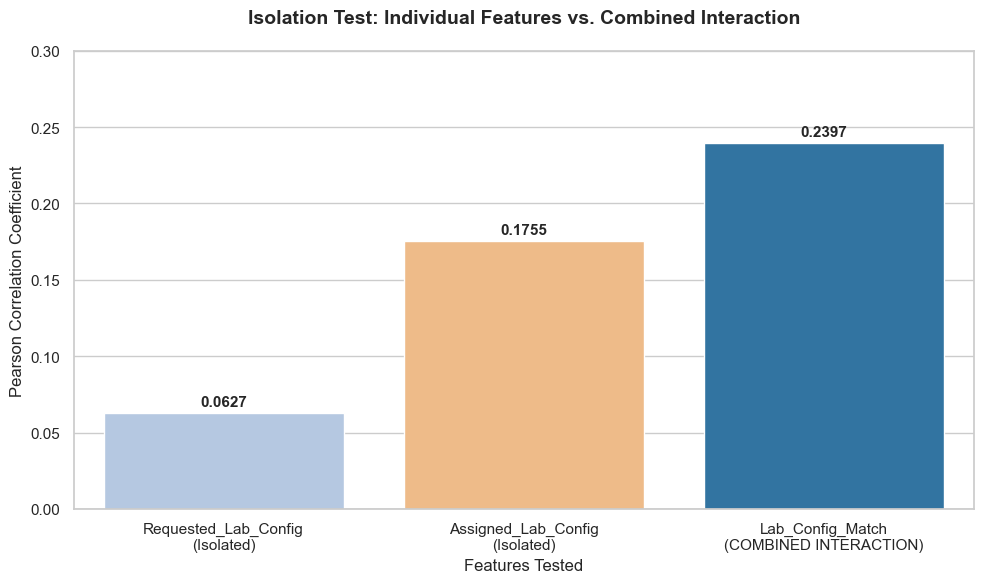

In [171]:
# 1. Temporarily encode the string columns to numbers just for the correlation calculation
requested_encoded = df_cleaned['Requested_Lab_Config'].astype('category').cat.codes
assigned_encoded = df_cleaned['Assigned_Lab_Config'].astype('category').cat.codes

# 2. Calculate individual correlations
corr_requested = requested_encoded.corr(df_cleaned['Dropped_Course'])
corr_assigned = assigned_encoded.corr(df_cleaned['Dropped_Course'])

# 3. Calculate the interaction feature correlation
df_cleaned['Lab_Config_Match'] = (df_cleaned['Requested_Lab_Config'] == df_cleaned['Assigned_Lab_Config']).astype(int)
interaction_corr = df_cleaned['Lab_Config_Match'].corr(df_cleaned['Dropped_Course'])

# 4. Prepare data for visualization
viz_data = pd.DataFrame({
    'Feature': ['Requested_Lab_Config\n(Isolated)', 'Assigned_Lab_Config\n(Isolated)', 'Lab_Config_Match\n(COMBINED INTERACTION)'],
    'Correlation': [corr_requested, corr_assigned, interaction_corr]
})

# 5. Generate the Plot
plt.figure(figsize=(10, 6))
# Using a distinct color palette to highlight the combined feature
colors = ['#aec7e8', '#ffbb78', '#1f77b4'] 
ax = sns.barplot(data=viz_data, x='Feature', y='Correlation', palette=colors)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', weight='bold', fontsize=11)

plt.title('Isolation Test: Individual Features vs. Combined Interaction', fontsize=14, pad=20, weight='bold')
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Features Tested', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Zero line reference
plt.ylim(0, 0.3) # Set limits to give some breathing room for labels
plt.tight_layout()

# Save the plot
plt.savefig('lab_config_isolation_test.png')
print("[V] The visualization 'lab_config_isolation_test.png' has been saved successfully!")

--- Interaction Feature Correlation ---
Lab_Config_Match correlation: 0.2397

--- Cancellation Rates by Config Match Status ---
                           Status  Total_Count  Cancellation_Rate
Mismatch (Got alternative config)         7013           0.079424
     Match (Got requested config)        56451           0.456006


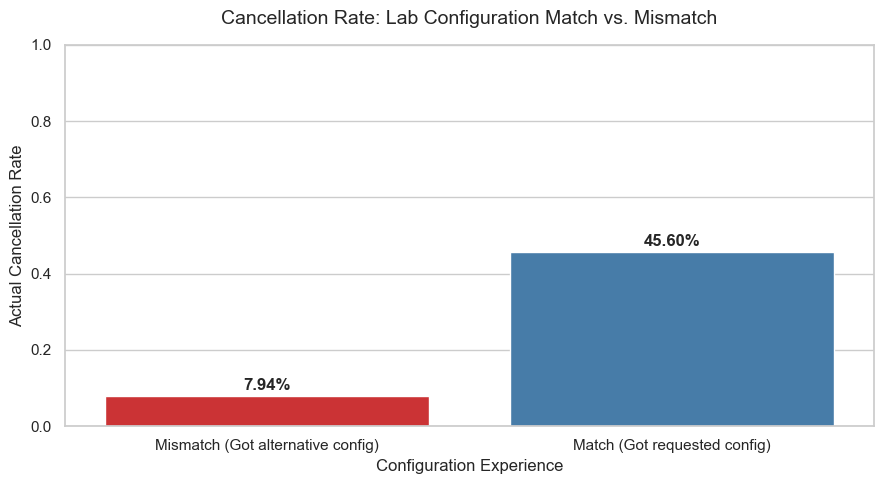

In [169]:
# 1. Create the interaction feature directly using string comparison (creates 1 and 0)
df_cleaned['Lab_Config_Match'] = (df_cleaned['Requested_Lab_Config'] == df_cleaned['Assigned_Lab_Config']).astype(int)

# 2. Now calculate Pearson correlation only between numerical columns and the target
interaction_corr = df_cleaned['Lab_Config_Match'].corr(df_cleaned['Dropped_Course'])
print("--- Interaction Feature Correlation ---")
print(f"Lab_Config_Match correlation: {interaction_corr:.4f}\n")

# 3. Aggregate actual cancellation rates based on the match status
summary = df_cleaned.groupby('Lab_Config_Match').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Status'] = summary['Lab_Config_Match'].map({0: 'Mismatch (Got alternative config)', 1: 'Match (Got requested config)'})

print("--- Cancellation Rates by Config Match Status ---")
print(summary[['Status', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))

# 4. Generate the EDA plot
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=summary, x='Status', y='Cancellation_Rate', palette='Set1')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Lab Configuration Match vs. Mismatch', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Configuration Experience')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('lab_config_interaction_eda.png')

#### Lab Configuration Match feature implementation

In [173]:
df_encoded['Lab_Config_Match'] = (df_encoded['Requested_Lab_Config'] == df_encoded['Assigned_Lab_Config']).astype(int)
columns_to_drop = ['Requested_Lab_Config', 'Assigned_Lab_Config']
df_encoded = df_encoded.drop(columns=columns_to_drop)